# Phase 1 — Establishing the Noise Problem

**Goal:** show that our sample covariance/correlation matrix sits deep in the
high-dimensional regime where a large share of its spectrum is *a priori* suspect, before
any filtering is attempted. This feeds the **Introduction** and the opening of
**Section 5 (Experiments)**.

## Notation (fixed here, reused throughout the paper)

- $R \in \mathbb{R}^{T \times N}$ — matrix of daily log returns from Phase 0
  ($T$ rows = days, $N$ columns = stocks).
- $\tilde R$ — column-standardized returns: $\tilde r_{t,i} = (r_{t,i} - \mu_i)/\sigma_i$
  with $\mu_i, \sigma_i$ the sample mean and (population, `ddof=0`) standard deviation of
  stock $i$. By construction each column of $\tilde R$ has mean 0 and variance 1.
- $C = \frac{1}{T}\tilde R^\top \tilde R$ — the sample **correlation** matrix
  ($\operatorname{diag}(C) = \mathbf 1$ exactly, given `ddof=0`).
- $q = N/T$ — the aspect ratio; eigenvalues $\lambda_1 \ge \dots \ge \lambda_N$ of $C$
  via `np.linalg.eigh`.
- Marchenko–Pastur (MP) edges for an i.i.d.-noise null with $\sigma^2 = 1$:
  $\lambda_\pm = (1 \pm \sqrt q\,)^2$.

**Why the correlation matrix (not raw covariance)?** Cross-sectional variance dispersion
is huge (microcaps vs. HDFC Bank); on the raw covariance it smears the noise bulk and
makes the MP comparison with a single $\sigma^2$ invalid. Standardizing each stock makes
$\sigma^2 = 1$ exact under the null, which is the convention of the founding literature
(Laloux et al. 1999; Plerou et al. 2002). Portfolio construction in later phases restores
the scale: $\Sigma = D^{1/2} C D^{1/2}$ with $D = \operatorname{diag}(\sigma_i^2)$.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10, "axes.titlesize": 11,
})

R = pd.read_parquet(DATA_DIR / "returns_daily.parquet")
meta = json.loads((DATA_DIR / "dataset_summary.json").read_text())
T, N = R.shape
q = N / T
assert (T, N) == (meta["T"], meta["N"])
print(f"loaded R: T={T} days x N={N} stocks   q = N/T = {q:.4f}")

# column-standardize (population std, so that diag(C)=1 exactly)
mu, sd = R.mean(axis=0), R.std(axis=0, ddof=0)
Rs = (R - mu) / sd
Rs.to_parquet(DATA_DIR / "returns_std.parquet")   # reused by Phases 2-4

C = (Rs.values.T @ Rs.values) / T
print(f"C: {C.shape}, symmetric: {np.allclose(C, C.T)}, "
      f"max |diag-1|: {np.abs(np.diag(C)-1).max():.2e}")

loaded R: T=1236 days x N=548 stocks   q = N/T = 0.4434
C: (548, 548), symmetric: True, max |diag-1|: 2.89e-15


## 1. The spectrum

`np.linalg.eigh` (exact, for symmetric matrices) — the randomized approximation enters
only in Phase 5. Eigenvalues are returned ascending; we index them descending so
$\lambda_1$ is the market mode.

In [2]:
lam_asc, V_asc = np.linalg.eigh(C)
lam = lam_asc[::-1]                # descending
V = V_asc[:, ::-1]                 # columns aligned with lam
tickers = list(R.columns)

np.savez_compressed(DATA_DIR / "eigen_phase1.npz",
                    lam=lam, V=V, tickers=np.array(tickers), q=q, T=T, N=N)

print(f"trace check: sum(lam) = {lam.sum():.4f}  (should be N = {N})")
print(f"lambda_1 (market) = {lam[0]:.2f}  ({lam[0]/N:.1%} of total variance)")
print(f"lambda_2..5 = {np.round(lam[1:5], 2)}")
print(f"lambda_min = {lam[-1]:.4f}")
print(f"condition number kappa(C) = {lam[0]/lam[-1]:.1f}")

top10 = pd.DataFrame({
    "eigenvalue": lam[:10],
    "% of variance": 100 * lam[:10] / N,
    "cumulative %": 100 * np.cumsum(lam[:10]) / N,
}, index=[f"lambda_{i+1}" for i in range(10)]).round(3)
top10

trace check: sum(lam) = 548.0000  (should be N = 548)
lambda_1 (market) = 130.24  (23.8% of total variance)
lambda_2..5 = [11.35  7.83  6.44  5.25]
lambda_min = 0.0433
condition number kappa(C) = 3007.9


,eigenvalue,% of variance,cumulative %
lambda_1,130.235,23.766,23.766
lambda_2,11.348,2.071,25.836
lambda_3,7.827,1.428,27.265
lambda_4,6.437,1.175,28.439
lambda_5,5.253,0.959,29.398
lambda_6,4.390,0.801,30.199
lambda_7,4.024,0.734,30.933
lambda_8,3.664,0.669,31.602
lambda_9,3.202,0.584,32.186
lambda_10,3.033,0.553,32.740


## 2. What pure noise would predict

Under the null that $\tilde R$ is i.i.d. noise ($\sigma^2 = 1$), as $N, T \to \infty$ with
$N/T \to q$, the eigenvalue density of $C$ converges to the Marchenko–Pastur law

$$f(\lambda) = \frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}{2\pi q \lambda},
\qquad \lambda_\pm = (1 \pm \sqrt q\,)^2 ,$$

supported entirely on $[\lambda_-, \lambda_+]$. **Every** eigenvalue of a pure-noise
matrix falls in this band (up to $O(N^{-2/3})$ Tracy–Widom edge fluctuations). So the
naive expectation under the null is: 100% of the spectrum inside the band, and any
eigenvalue above $\lambda_+$ carries structure the null cannot explain.

In [3]:
sq = np.sqrt(q)
lam_minus, lam_plus = (1 - sq)**2, (1 + sq)**2
print(f"q = {q:.4f}  ->  MP band [{lam_minus:.4f}, {lam_plus:.4f}]")

inside = ((lam >= lam_minus) & (lam <= lam_plus)).sum()
above  = (lam > lam_plus).sum()
below  = (lam < lam_minus).sum()
print(f"\ninside the band : {inside:4d}  ({inside/N:.1%})")
print(f"above lambda_+  : {above:4d}  ({above/N:.1%})   <- candidate signal modes")
print(f"below lambda_-  : {below:4d}  ({below/N:.1%})")

var_above = lam[lam > lam_plus].sum() / N
print(f"\nvariance carried by the {above} above-band modes: {var_above:.1%}")
print(f"variance carried by the {inside} in-band modes   : {lam[(lam >= lam_minus) & (lam <= lam_plus)].sum()/N:.1%}")

# effective rank (Shannon) — how many 'effective' independent modes the matrix has
p = lam / lam.sum()
eff_rank = np.exp(-(p * np.log(p)).sum())
print(f"\neffective rank exp(H(p)) = {eff_rank:.1f}  of N = {N}")

# market-mode structure: participation ratio and sign uniformity
pr = 1.0 / np.sum(V[:, 0]**4)
v1 = V[:, 0] * np.sign(V[:, 0].sum())
print(f"market mode: participation ratio = {pr:.0f}/{N}, "
      f"positive components = {(v1 > 0).sum()}/{N}")

q = 0.4434  ->  MP band [0.1117, 2.7751]

inside the band :  496  (90.5%)
above lambda_+  :   11  (2.0%)   <- candidate signal modes
below lambda_-  :   41  (7.5%)

variance carried by the 11 above-band modes: 33.3%
variance carried by the 496 in-band modes   : 66.1%

effective rank exp(H(p)) = 154.5  of N = 548
market mode: participation ratio = 478/548, positive components = 548/548


## 3. Figure: the spectrum against the noise band

Panel (a): the full sorted spectrum on a log scale with the MP band shaded — the bulk
hugs the band, a handful of modes escape it, and the market mode sits far to the right.
Panel (b): cumulative variance — the striking fact that the vast majority of eigenvalues
contribute a thin tail of variance. (The MP *density* overlay and KS test are Phase 2's
Figure 1; this figure motivates, that one validates.)

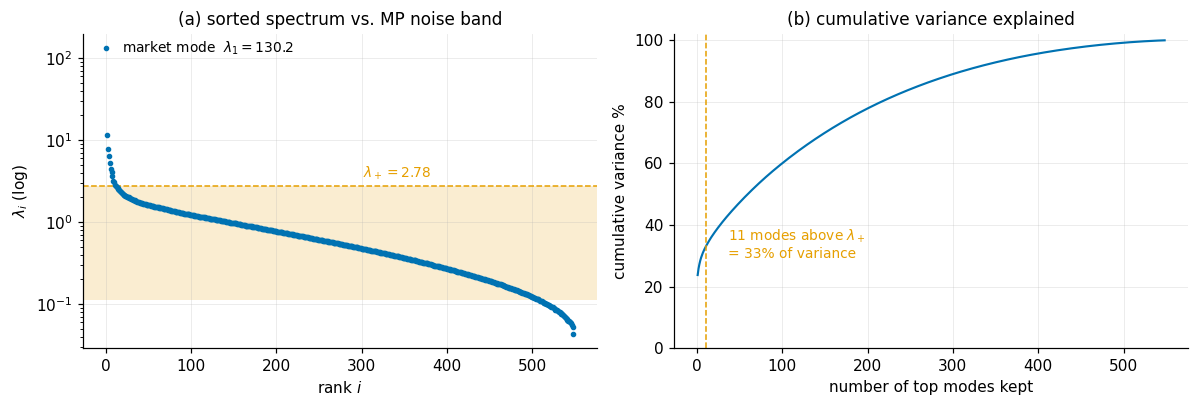

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

idx = np.arange(1, N + 1)
axes[0].axhspan(lam_minus, lam_plus, color=PALETTE[1], alpha=0.18, lw=0)
axes[0].scatter(idx, lam, s=7, color=PALETTE[0], zorder=3)
axes[0].set_yscale("log")
axes[0].axhline(lam_plus, color=PALETTE[1], lw=1, ls="--")
axes[0].annotate(f"$\\lambda_+ = {lam_plus:.2f}$", xy=(N*0.55, lam_plus),
                 xytext=(0, 5), textcoords="offset points", color=PALETTE[1], fontsize=9)
axes[0].annotate(f"market mode  $\\lambda_1 = {lam[0]:.1f}$", xy=(1, lam[0]),
                 xytext=(10, -3), textcoords="offset points", fontsize=9)
axes[0].set_xlabel("rank $i$"); axes[0].set_ylabel("$\\lambda_i$ (log)")
axes[0].set_title("(a) sorted spectrum vs. MP noise band")

cum = 100 * np.cumsum(lam) / N
axes[1].plot(idx, cum, color=PALETTE[0], lw=1.4)
axes[1].axvline(above, color=PALETTE[1], lw=1, ls="--")
axes[1].annotate(f"{above} modes above $\\lambda_+$\n= {cum[above-1]:.0f}% of variance",
                 xy=(above, cum[above-1]), xytext=(14, -8), textcoords="offset points",
                 fontsize=9, color=PALETTE[1])
axes[1].set_xlabel("number of top modes kept"); axes[1].set_ylabel("cumulative variance %")
axes[1].set_ylim(0, 102)
axes[1].set_title("(b) cumulative variance explained")

fig.tight_layout()
fig.savefig(DATA_DIR / "fig_phase1_spectrum.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Why this matters for portfolios (teaser for Experiment 4)

The full-sample $q = N/T \approx 0.44$ is already problematic, but the *operational*
setting is worse: a practitioner estimating risk from a rolling one-year window has
$T = 252 < N$, where the sample covariance is **rank-deficient by construction** —
minimum-variance weights $w \propto \Sigma^{-1}\mathbf 1$ do not even exist without
regularization. We demonstrate on the last 252 days of our sample.

In [5]:
Rw = R.iloc[-252:]
Cw = np.cov(Rw.values, rowvar=False)
lw = np.linalg.eigvalsh(Cw)[::-1]
rank = (lw > lw[0] * 1e-10).sum()
qw = N / 252
print(f"252-day window: q = {qw:.2f} > 1")
print(f"numerical rank of the 252-day sample covariance: {rank} of {N}")
print(f"zero eigenvalues: {N - rank}  ->  matrix is singular, w = Sigma^-1 1 undefined")
print(f"\n(even at the full-sample q={q:.2f}, kappa(C) = {lam[0]/lam[-1]:.0f} -- "
      f"inversion amplifies estimation error by orders of magnitude)")

252-day window: q = 2.17 > 1
numerical rank of the 252-day sample covariance: 248 of 548
zero eigenvalues: 300  ->  matrix is singular, w = Sigma^-1 1 undefined

(even at the full-sample q=0.44, kappa(C) = 3008 -- inversion amplifies estimation error by orders of magnitude)


## 5. Draft text for the Introduction / Section 5 opening

Generated with the actual numbers; edit prose, keep numbers wired to the data.

In [6]:
draft = f'''For our sample of N = {N} NSE equities over T = {T} trading days, the
aspect ratio is q = N/T = {q:.3f}. Under the null hypothesis that standardized returns
are pure i.i.d. noise, the Marchenko-Pastur law confines the entire spectrum of the
sample correlation matrix to [{lam_minus:.3f}, {lam_plus:.3f}]. Empirically,
{inside} of {N} eigenvalues ({inside/N:.1%}) fall inside this band, while only
{above} ({above/N:.1%}) exceed its upper edge -- led by the market mode at
lambda_1 = {lam[0]:.1f}, which alone accounts for {lam[0]/N:.1%} of total variance.
The {above} above-band modes jointly carry {var_above:.1%} of the variance, leaving the
overwhelming majority of the spectrum statistically indistinguishable, at this level of
description, from sampling noise. Sections 5.1-5.2 subject this bulk to two independent
tests (MP density and GOE spacing statistics); the effective rank of the correlation
matrix is just {eff_rank:.0f}, and at the one-year estimation horizon used in practice
(T = 252 < N), the sample covariance is singular outright -- rank {rank} of {N} in our
final window. Any use of Sigma^-1, the central object of mean-variance analysis, is
therefore impossible without regularization, motivating the spectral cleaning that
this paper evaluates.'''

print(draft)
(DATA_DIR / "section_intro_noise_draft.md").write_text(draft)
print("\nsaved -> data/section_intro_noise_draft.md")

For our sample of N = 548 NSE equities over T = 1236 trading days, the
aspect ratio is q = N/T = 0.443. Under the null hypothesis that standardized returns
are pure i.i.d. noise, the Marchenko-Pastur law confines the entire spectrum of the
sample correlation matrix to [0.112, 2.775]. Empirically,
496 of 548 eigenvalues (90.5%) fall inside this band, while only
11 (2.0%) exceed its upper edge -- led by the market mode at
lambda_1 = 130.2, which alone accounts for 23.8% of total variance.
The 11 above-band modes jointly carry 33.3% of the variance, leaving the
overwhelming majority of the spectrum statistically indistinguishable, at this level of
description, from sampling noise. Sections 5.1-5.2 subject this bulk to two independent
tests (MP density and GOE spacing statistics); the effective rank of the correlation
matrix is just 155, and at the one-year estimation horizon used in practice
(T = 252 < N), the sample covariance is singular outright -- rank 248 of 548 in our
final window. 

## What to write where

- **Introduction:** the paragraph above, nearly verbatim — it states the problem with
  our own numbers and previews the two-layer validation.
- **Section 2 (Background):** the notation block at the top of this notebook.
- **Results:** Figure `fig_phase1_spectrum.png` as the motivating figure; the top-10
  eigenvalue table if space permits.
- Note for Phase 2: $\sigma^2 = 1$ is exact by construction here, but the presence of
  the market mode *depletes* the bulk's effective variance; Phase 2 should therefore fit
  the MP density with an effective $\sigma^2_{\text{eff}} < 1$ (standard practice:
  Laloux et al. treat $\sigma^2$ as a fit parameter, or set
  $\sigma^2_{\text{eff}} = 1 - \sum_{\text{above}}\lambda_i / N$).